In [ ]:
'''
Script to call for finding the transformation to template using either ridge regression (warp) or generalized procrustes.
'''
import argparse,os,sys
import numpy as np
import neuroboros as nb
from shared_utils.data_io_utils import parse_range,return_Tian_labels,return_aseg_labels,get_dm,get_rois_and_space
from shared_utils.resource_management_utils import print_memory_usage,save_args_to_json,load_args_from_json,merge_args
from shared_utils.hyperalignment_utils import calculate_connectivity,get_target_ts,reliability_weighting_ridge,evaluate_transformation

In [21]:
args = load_args_from_json('./config_align_example.json')
print(args)
args = argparse.Namespace(**args)

{'load_json': 'config_align_example.json', 'dataset': 'Budapest', 'outroot': '/dartfs/rc/lab/H/HaxbyLab/jiaxin/subcortical_hyperalignment/', 'extra_str': 'ridgeCV', 'seeds': 'aseg', 'targets': ['onavg-ico8'], 'task': 'budapest', 'run': [1, 2, 3], 'subj': [13, 14], 'template_dir': '/dartfs/rc/lab/H/HaxbyLab/jiaxin/subcortical_hyperalignment/templates', 'transform_dir': '', 'searchlight_radius': 20, 'searchlight_center': 'onavg-ico32', 'notweighted': False, 'surface_space': 'onavg-ico32', 'volume_space': 'mni-2mm', 'surface_resample': '1step_pial_overlap', 'volume_resample': '1step_linear_overlap', 'prep': 'default', 'zscore_axis': 'searchlight', 'separate_zscore': True, 'saved_beta_root': '/dartfs/rc/lab/H/HaxbyLab/datasets/', 'dry_run': False, 'stage': 'align', 'saved_beta_path': '/dartfs/rc/lab/H/HaxbyLab/datasets/saved_confound_betas/default/Budapest', 'alignfunc': 'ridgeCV', 'ridge_alpha': [10.0, 100.0, 1000.0, 10000.0, 100000.0, 1000000.0, 10000000.0, 100000000.0]}


In [22]:
args.stage = "align"
if 'saved_beta_root' in args and os.path.exists(args.saved_beta_root):
    args.saved_beta_path = os.path.join(args.saved_beta_root,'saved_confound_betas',args.prep,args.dataset)
if not isinstance(args.targets,list):
        args.targets = [args.targets]
if 'transform_dir' in args and os.path.exists(args.transform_dir):
    args.outdir = args.transform_dir
else:
    seedrois,seedspace = get_rois_and_space(args.seeds,args.surface_space,args.volume_space)
    if seedspace == args.surface_space:
        args.outdir = os.path.join(args.outroot,args.dataset,f'{args.surface_space}_{args.surface_resample}',args.extra_str,'transformations_to_template')
    else:
        args.outdir = os.path.join(args.outroot,args.dataset,f'{args.volume_space}_{args.volume_resample}',args.extra_str,'transformations_to_template')
    args.transform_dir = args.outdir
if not('template_dir' in args and os.path.exists(args.template_dir)):
    if seedspace == args.surface_space:
        args.template_dir = os.path.join(args.outroot,args.dataset,f'{args.surface_space}_{args.surface_resample}','templates')
    else:
        args.template_dir = os.path.join(args.outroot,args.dataset,f'{args.volume_space}_{args.volume_resample}','templates')
# config_path = save_args_to_json(args)

kwargs = { # for older datasets, there might be multiple versions/folders
'space': [args.surface_space, args.volume_space],
'resample': [args.surface_resample,args.volume_resample],
'prep':args.prep
}   
if args.dataset.lower() in ["budapest", "raiders"]:
    dset=nb.datasets.datasets[args.dataset.lower()](fp_version="20.2.7",**kwargs)
elif args.dataset.lower() in nb.datasets.datasets.keys():
    dset=nb.datasets.datasets[args.dataset.lower()](**kwargs)
else:
    ValueError("Unsupported Dataset")
sids = np.array(dset.subjects)[args.subj]

if args.zscore_axis=="searchlight":
    zscore_ax = 0
elif args.zscore_axis=="fullmatrix":
    zscore_ax = None
else:
    raise ValueError("Unsupported zscore_axis")

os.makedirs(args.outdir, exist_ok=True)    

In [10]:
args.outdir

'/dartfs/rc/lab/H/HaxbyLab/jiaxin/subcortical_hyperalignment/Budapest/mni-2mm_1step_linear_overlap/ridgeCV/transformations_to_template'

In [23]:
args.template_dir

'/dartfs/rc/lab/H/HaxbyLab/jiaxin/subcortical_hyperalignment/Budapest/mni-2mm_1step_linear_overlap/templates'

In [ ]:
# def calc_target_ts_single_subj(dset,sid,target,task,run,saved_beta_path=None):
#     targetrois,targetspace = get_rois_and_space(target,dset.surface_space,dset.volume_space)
#     target_ts = get_dm(dset, sid, targetrois, task, run, targetspace,
#             atlas=target,saved_beta_path=saved_beta_path,array_output=False)
#     if target.startswith('onavg'):
#         MAPPINGS = {roi:nb.mapping(roi, dset.surface_space, target, mask=True) for roi in targetrois}
#         target_ts = get_target_ts(target_ts,'mapping',target_item=MAPPINGS)
#     else:
#         target_ts = get_target_ts(target_ts,'searchlight_mean')                
#     return target_ts
# from scipy.stats import zscore
# def calc_dm_across_runs(dset,sid,roi,seedspace,targets,seeds,task,run,saved_beta_path=None,zscore_axis=0,separate_zscore=True):
#     dm_allruns = []
#     for curr_run in run:
#         seed_ts = get_dm(dset,sid,roi,task,curr_run, seedspace,atlas=seeds,saved_beta_path=saved_beta_path,array_output=True)
#         dm = []
#         for target in targets:
#             if target == "None":
#                 raise ValueError("Transformations not needed for anatomical alignment. Exiting")
#             else:
#                 if target == 'response':
#                     dm_allruns.append(seed_ts) 
#                 else:
#                     target_ts = calc_target_ts_single_subj(dset,sid, target, task, curr_run,saved_beta_path=args.saved_beta_path)   
#                     if separate_zscore:
#                         dm.append(calculate_connectivity(target_ts,seed_ts,zscore_axis=zscore_axis,z=True))
#                     else:
#                         dm.append(calculate_connectivity(target_ts,seed_ts,zscore_axis=zscore_axis,z=False))
#                     dm = np.concatenate(dm,axis=0)
#                     if not separate_zscore:
#                         dm = np.nan_to_num(zscore(dm, axis=zscore_axis, nan_policy='omit'))
#                     dm_allruns.append(dm)
#     return np.stack(dm_allruns,axis=0)

In [15]:
from neuroboros.stats import cronbach_alpha

seedrois,seedspace = get_rois_and_space(args.seeds,dset.surface_space,dset.volume_space)
sid = sids[0]
roi = seedrois[0]
dm_allruns = calc_dm_across_runs(dset,sid, roi, seedspace, args.targets,args.seeds,args.task,args.run,args.saved_beta_path,zscore_axis=zscore_ax,separate_zscore=args.separate_zscore)

In [52]:
dm_allruns = calc_dm_across_runs(dset,sid, roi, seedspace, args.targets,args.seeds,args.task,[1],args.saved_beta_path,zscore_axis=zscore_ax,separate_zscore=args.separate_zscore)
dm_allruns.shape

(1, 1210, 89)

In [51]:
calpha = cronbach_alpha(dm_allruns,rep_axis=0,var_axis=1)
print(calpha.shape)

(10152,)


In [27]:
from glob import glob
files = glob(os.path.join(args.template_dir,f'*targets_cortical-lr_{roi.replace("_subj","")}.npy'))
print(files)
assert len(files)==1
tmpl = np.load(files[0])

['/dartfs/rc/lab/H/HaxbyLab/jiaxin/subcortical_hyperalignment/Budapest/mni-2mm_1step_linear_overlap/templates/targets_cortical-lr_l-accumbens.npy']


In [ ]:
# without reliability
avg_mse_train = np.zeros((len(args.ridge_alpha)))
avg_mse_val = np.zeros((len(args.ridge_alpha)))
for ii,alpha in enumerate(args.ridge_alpha):
    print(ii,alpha)
    avg_mse_train[ii],avg_mse_val[ii] = loo_cv(dm_allruns, tmpl, alpha, reliability=None)

best_idx = np.argmin(avg_mse_val)
best_alpha = args.ridge_alpha[best_idx]   
X = np.mean(dm_allruns,axis=0)
R_final = reliability_weighting_ridge(
        X, tmpl, calpha, best_alpha
    )
np.save(out_fn,R_final)

avg_mse_train_reliability_weighted = np.zeros((len(args.ridge_alpha)))
avg_mse_val_reliability_weighted = np.zeros((len(args.ridge_alpha)))
# with reliability
calpha = cronbach_alpha(dm_allruns,rep_axis=0,var_axis=1)
print(calpha.shape)
for ii,alpha in enumerate(args.ridge_alpha):
    print(ii,alpha)
    avg_mse_train_reliability_weighted[ii],avg_mse_val_reliability_weighted[ii] = loo_cv(dm_allruns, tmpl, alpha, reliability=calpha)

0 10.0
1 100.0
2 1000.0
3 10000.0
4 100000.0
5 1000000.0
6 10000000.0
7 100000000.0
(89,)
0 10.0
1 100.0
2 1000.0
3 10000.0
4 100000.0
5 1000000.0
6 10000000.0
7 100000000.0


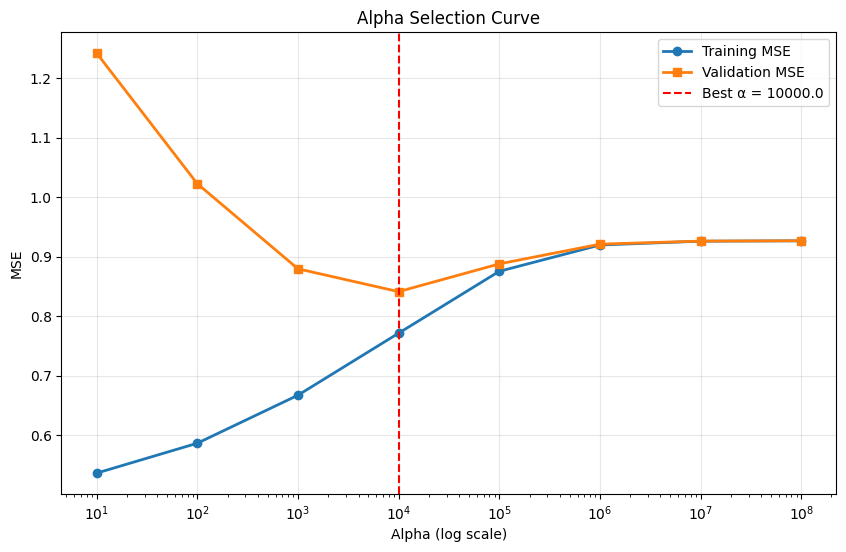

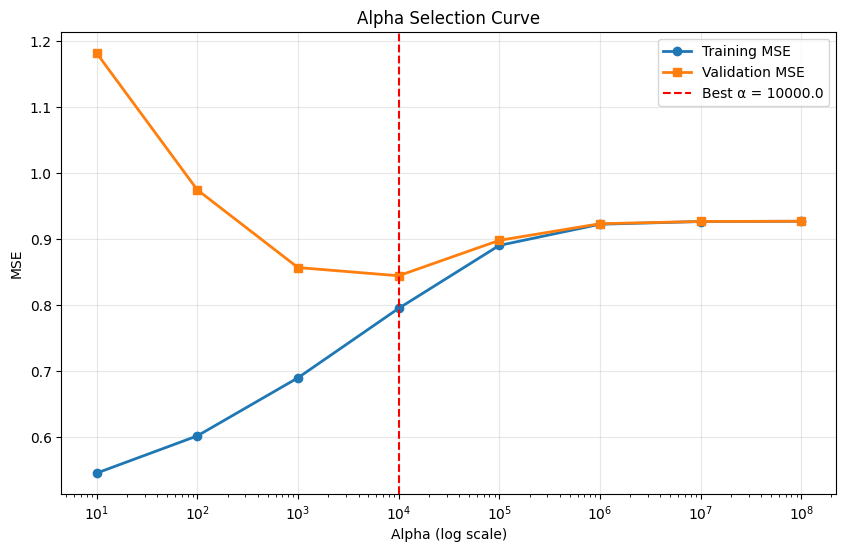

In [31]:
import matplotlib.pyplot as plt
best_idx = np.argmin(avg_mse_val)
best_alpha = args.ridge_alpha[best_idx]
plt.figure(figsize=(10, 6))
plt.semilogx(args.ridge_alpha, avg_mse_train, 'o-', label='Training MSE', linewidth=2)
plt.semilogx(args.ridge_alpha, avg_mse_val, 's-', label='Validation MSE', linewidth=2)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best α = {best_alpha}')
plt.xlabel('Alpha (log scale)')
plt.ylabel('MSE')
plt.title('Alpha Selection Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_idx = np.argmin(avg_mse_val_reliability_weighted)
best_alpha = args.ridge_alpha[best_idx]
plt.figure(figsize=(10, 6))
plt.semilogx(args.ridge_alpha, avg_mse_train_reliability_weighted, 'o-', label='Training MSE', linewidth=2)
plt.semilogx(args.ridge_alpha, avg_mse_val_reliability_weighted, 's-', label='Validation MSE', linewidth=2)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best α = {best_alpha}')
plt.xlabel('Alpha (log scale)')
plt.ylabel('MSE')
plt.title('Alpha Selection Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
from hyperalignment.linalg import safe_svd

In [35]:
X = np.mean(dm_allruns,axis=0)
U, s, Vt = safe_svd(X, remove_mean=False)
print(s.shape)

(89,)


In [39]:
print(alpha)
d = s / (alpha + s**2)
print(d.shape)

100000000.0
(89,)


In [44]:
from hyperalignment.procrustes import procrustes

In [ ]:
W_reliability = np.diag(weights)
X_scaled = X @ W_reliability  # (16, 285)
T_scaled = procrustes(X_scaled,tmpl)
T_original = W_reliability @ T_scaled
print(T_scaled.shape)

(89, 89)


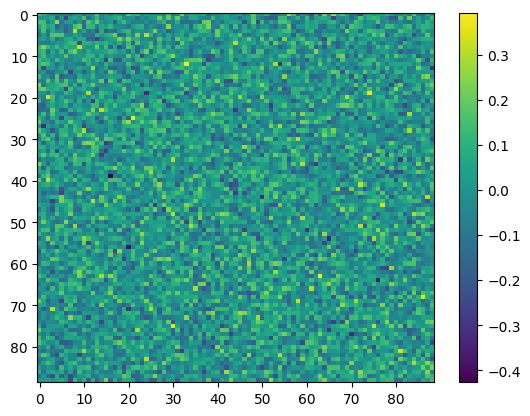

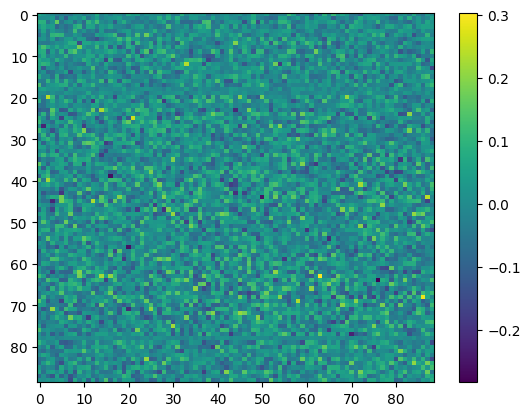

In [48]:
plt.figure()
plt.imshow(T_scaled,aspect='auto')
plt.colorbar()
plt.figure()
plt.imshow(T_original,aspect='auto')
plt.colorbar()